Stimulus coordinates shape: (272, 3)
Electrodes shape: (1031, 3)


Running AlievPanfilov on [269, 279, 240] Grid: 100%|████████████████████████████████▉| 6666/6667 [01:27<00:00, 75.96it/s]


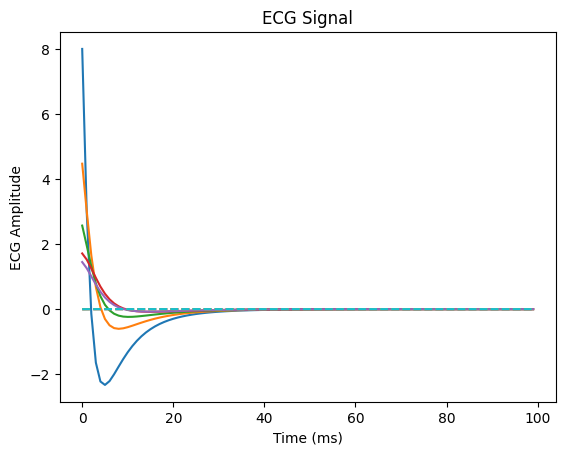

In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

# path = Path(__file__).parents[1]
# path = Path("/Users/arstanbek/Projects/fibrosis/FibrosisOptimization/data/models/left_ventricle/LV")

path = Path("/home/arstanbekokenov/projects/fibrosisoptimization/data/exp_apex/")

# Load mesh as cubic array
mesh = np.load(path.joinpath("0", "tissue.npy"))
# fibers = np.load(path.joinpath("data", "fibers.npy"))
# print("Mesh shape:", mesh.shape)
# print("Fibers shape:", fibers.shape)
# fibers_mesh = np.zeros((*mesh.shape, 3))
# print("Fibers mesh shape:", fibers_mesh.shape)
# fibers_mesh[mesh > 0, :] = fibers[..., :]

stim_coords = np.load(path.joinpath("stimuls_coords.npy"))
electrodes_epi = np.load(path.joinpath("electrodes_epi.npy"))
electrodes_endo = np.load(path.joinpath("electrodes_endo.npy"))
electrodes = np.vstack((electrodes_epi, electrodes_endo))[:, :3]
# electrodes = electrodes_endo[:100, :3]
print("Stimulus coordinates shape:", stim_coords.shape)
print("Electrodes shape:", electrodes.shape)
stim_matrix = np.zeros(mesh.shape)
stim_matrix[tuple(stim_coords.T)] = 1

z_min = np.min(mesh.nonzero()[0])

n, m, k = mesh.shape

tissue = fw.CardiacTissueGrid([n, m, k])
tissue.mesh = mesh
# tissue.fibers = fibers_mesh
# tissue.mesh[np.random.rand(n, m) < 0.3] = 2  # introduce some inexcitable regions

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
# stim_sequence.add_stim(fw.StimVoltageCoord(0, 1, 0, n, 0, m, z_min, z_min + 5))
stim_sequence.add_stim(fw.StimVoltageMatrix(0, 1, stim_matrix))

# mesh_builder = fw.VisMeshBuilder3D()
# mesh_grid = mesh_builder.build_mesh(stim_matrix)
# mesh_grid.plot()

ecg_tracker = fw.ECGGridTracker(measure_coords=electrodes, distance_power=2)
ecg_tracker.start_time = 0.1
ecg_tracker.step = 66
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(ecg_tracker)

simulation = fw.CardiacSimulation()
simulation.dt = 0.0015
simulation.dr = 0.1
simulation.t_max = 10
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.AlievPanfilov(memory_save=True)
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run(num_of_threads=32)
u = simulation.cardiac_model.u

plt.figure()
plt.plot(ecg_tracker.output[:, :5])
plt.plot(ecg_tracker.output[:, -5:], '--')
plt.title("ECG Signal")
plt.xlabel("Time (ms)")
plt.ylabel("ECG Amplitude")
plt.show()

# # visualize the ventricle in 3D
# mesh_builder = fw.VisMeshBuilder3D()
# mesh_grid = mesh_builder.build_mesh(tissue.mesh)
# mesh_grid = mesh_builder.add_scalar(u, 'u')
# mesh_grid.plot(clim=[0, 1], cmap='viridis')


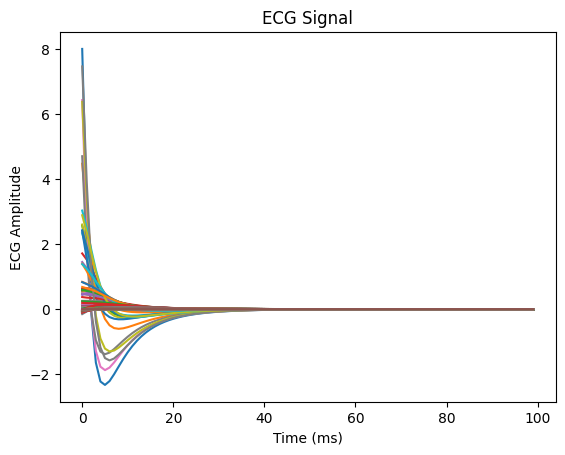

In [13]:
n_epi = electrodes_epi.shape[0]
plt.figure()
plt.plot(ecg_tracker.output[:, :n_epi])
# plt.plot(ecg_tracker.output[:, -5:], '--')
plt.title("ECG Signal")
plt.xlabel("Time (ms)")
plt.ylabel("ECG Amplitude")
plt.show()


In [8]:
electrodes_epi.shape, electrodes_endo.shape

((566, 3), (465, 3))